# Model Architecture - Build, Verify, Convert

**Notebook role:** Phase 4. Builds all three model variants, verifies their forward pass shapes, runs INT8 TFLite conversion to measure real binary sizes, and produces an `eda_model.pdf` briefing for the report.

**Outputs**
- `other_files/figs_eda/model_*.png` -- architecture and sizing figures
- `other_files/eda_model.pdf` -- briefing PDF
- `other_files/tflite_models/*.tflite` -- one TFLite file per variant (untrained, for size verification only)

**What we check**
1. All three variants build without errors
2. Forward pass produces correct output shapes and value ranges
3. INT8 TFLite conversion fits under the 800 KB flash budget
4. Tensor arena estimate fits under the 400 KB SRAM budget
5. The op set contains only TFLM-supported operations


## 0. Setup

In [1]:
import sys, os, tempfile
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

ROOT = Path("..").resolve()
OTHER_FILES = ROOT / "other_files"
sys.path.insert(0, str(OTHER_FILES))

from model import (
    build_model, convert_to_tflite, get_default_losses_and_weights,
    MODEL_VARIANTS,
    T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ,
    GRID_H, GRID_W, COUNT_CLASSES,
)

FIG_DIR     = OTHER_FILES / "figs_eda"
TFLITE_DIR  = OTHER_FILES / "tflite_models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

# Targets from the assignment
ESP32_FLASH_KB = 800
ESP32_SRAM_KB  = 400

print(f"TensorFlow: {tf.__version__}")
print(f"Variants:   {list(MODEL_VARIANTS)}")
print(f"Input:      ({T_CONTEXT}, {N_RADARS}, {N_ANT}, {N_BINS}, {N_IQ})")
print(f"Output:     heatmap ({GRID_H}, {GRID_W}, 1) + count ({COUNT_CLASSES},)")
print(f"Budgets:    {ESP32_FLASH_KB} KB flash, {ESP32_SRAM_KB} KB SRAM")


I0000 00:00:1777590611.350456   82831 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777590615.550047   82831 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
Variants:   ['small', 'medium', 'large']
Input:      (8, 6, 3, 105, 2)
Output:     heatmap (36, 24, 1) + count (5,)
Budgets:    800 KB flash, 400 KB SRAM


## 1. Build all three variants

Build each variant and print a Keras `summary()` for the small one (the structure is identical for all three; only the channel widths differ).


In [2]:
variants = {}
for name in MODEL_VARIANTS:
    m = build_model(name)
    variants[name] = m
    print(f"  {name:>8s}: {m.count_params():>9,} params")


     small:   119,350 params
    medium:   320,970 params
     large:   624,382 params


In [3]:
print("Architecture summary (variant: small)\n")
variants["small"].summary(line_length=110)


Architecture summary (variant: small)



Model: "uwb_localization_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ cir_stack (InputLayer)         │ (None, 8, 6, 3, 105, 2)   │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ permute_to_TBRAIQ (Permute)    │ (None, 8, 105, 6, 3, 2)   │                0 │ cir_stack[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ reshape_to_image (Reshape)     │ (None, 8, 105, 36)        │                0 │ permute_to_TBRAIQ[0][0]    │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ dw_time (DepthwiseConv2D)      │ (None, 1, 105, 36)        │              288 │ reshape_to_image[0][0]     │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ bn_dw (BatchNormalization)     │ (None, 1, 105, 36)        │              144 │ dw_time[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ relu_dw (ReLU)                 │ (None, 1, 105, 36)        │                0 │ bn_dw[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv0_pw (Conv2D)              │ (None, 1, 105, 32)        │            1,152 │ relu_dw[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ bn0 (BatchNormalization)       │ (None, 1, 105, 32)        │              128 │ conv0_pw[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ relu0 (ReLU)                   │ (None, 1, 105, 32)        │                0 │ bn0[0][0]                  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv1 (Conv2D)                 │ (None, 1, 105, 48)        │            7,680 │ relu0[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ bn1 (BatchNormalization)       │ (None, 1, 105, 48)        │              192 │ conv1[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ relu1 (ReLU)                   │ (None, 1, 105, 48)        │                0 │ bn1[0][0]                  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2 (Conv2D)                 │ (None, 1, 53, 64)         │           15,360 │ relu1[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ bn2 (BatchNormalization)       │ (None, 1, 53, 64)         │              256 │ conv2[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ relu2 (ReLU)                   │ (None, 1, 53, 64)         │                0 │ bn2[0][0]                  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv3 (Conv2D)                 │ (None, 1, 27, 96)         │           18,432 │ relu2[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ bn3 (BatchNormalization)       │ (None, 1, 27, 96)         │              384 │ conv3[0][0]                │
├───

 Total params: 119,350 (466.21 KB)

 Trainable params: 118,606 (463.30 KB)

 Non-trainable params: 744 (2.91 KB)

## 2. Variant configurations

The three variants share the same architecture (encoder + heatmap decoder + count head) but differ in channel widths.


In [4]:
print(f"{'':>8s}  {'enc filters':<24s}  {'feat':>5s}  {'c_b':>4s}  {'decoder ch':<16s}  {'count h':>8s}")
print("-" * 90)
for name, v in MODEL_VARIANTS.items():
    print(f"{name:>8s}  {str(v.enc_filters):<24s}  {v.feature_width:>5d}  "
          f"{v.bottleneck_chan:>4d}  {str(v.decoder_channels):<16s}  {v.count_hidden:>8d}")


          enc filters                feat   c_b  decoder ch         count h
------------------------------------------------------------------------------------------
   small  (32, 48, 64, 96)             96     8  (48, 32, 16)            48
  medium  (48, 80, 112, 160)          160    12  (80, 56, 28)            80
   large  (64, 112, 160, 224)         224    16  (112, 80, 40)          128


## 3. Forward pass verification

Run a dummy batch through each model and verify output shapes and value ranges.


In [5]:
print(f"{'variant':>8s}  {'heatmap':>20s}  {'count':>15s}  {'hm range':>15s}  {'cnt sum':>8s}")
print("-" * 75)

forward_results = {}
for name, m in variants.items():
    x = np.random.randn(2, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ).astype(np.float32)
    out = m(x, training=False)
    if isinstance(out, dict):
        hm = out["heatmap"].numpy()
        cnt = out["count"].numpy()
    else:
        d = dict(zip(m.output_names, out))
        hm = d["heatmap"].numpy()
        cnt = d["count"].numpy()
    hm_range = (hm.min(), hm.max())
    cnt_sum = cnt.sum(axis=1)
    forward_results[name] = (hm, cnt)
    print(f"{name:>8s}  {str(hm.shape):>20s}  {str(cnt.shape):>15s}  "
          f"[{hm_range[0]:.3f}, {hm_range[1]:.3f}]   {cnt_sum.mean():.4f}")


 variant               heatmap            count         hm range   cnt sum
---------------------------------------------------------------------------
   small        (2, 36, 24, 1)           (2, 5)  [0.499, 0.503]   1.0000
  medium        (2, 36, 24, 1)           (2, 5)  [0.499, 0.501]   1.0000
   large        (2, 36, 24, 1)           (2, 5)  [0.499, 0.501]   1.0000


## 4. Architecture diagram (block-level)

A schematic of the data flow that's identical across variants.


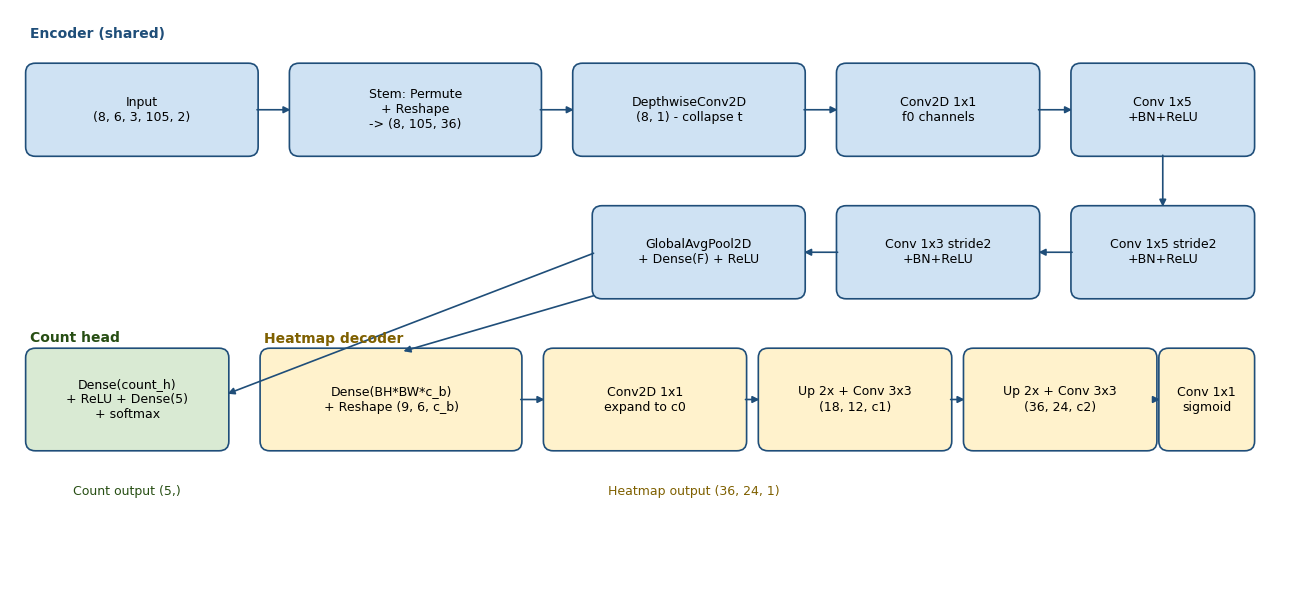

In [6]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis("off")

def block(x, y, w, h, label, color="#cfe2f3"):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=1.2, edgecolor="#1f4e79", facecolor=color,
    ))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=9)

def arrow(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle="-|>", mutation_scale=10, linewidth=1.2, color="#1f4e79",
    ))

# Encoder column
block(0.2, 4.5, 2.3, 0.9, "Input\n(8, 6, 3, 105, 2)")
block(2.9, 4.5, 2.5, 0.9, "Stem: Permute\n+ Reshape\n-> (8, 105, 36)")
block(5.8, 4.5, 2.3, 0.9, "DepthwiseConv2D\n(8, 1) - collapse t")
block(8.5, 4.5, 2.0, 0.9, "Conv2D 1x1\nf0 channels")
block(10.9, 4.5, 1.8, 0.9, "Conv 1x5\n+BN+ReLU")
arrow(2.5, 4.95, 2.9, 4.95); arrow(5.4, 4.95, 5.8, 4.95)
arrow(8.1, 4.95, 8.5, 4.95); arrow(10.5, 4.95, 10.9, 4.95)

# Encoder continued
block(10.9, 3.0, 1.8, 0.9, "Conv 1x5 stride2\n+BN+ReLU")
block(8.5, 3.0, 2.0, 0.9, "Conv 1x3 stride2\n+BN+ReLU")
block(6.0, 3.0, 2.1, 0.9, "GlobalAvgPool2D\n+ Dense(F) + ReLU")
arrow(11.8, 4.5, 11.8, 3.9)
arrow(10.9, 3.45, 10.5, 3.45); arrow(8.5, 3.45, 8.1, 3.45)

# Two heads
block(2.6, 1.4, 2.6, 1.0, "Dense(BH*BW*c_b)\n+ Reshape (9, 6, c_b)", color="#fff2cc")
block(5.5, 1.4, 2.0, 1.0, "Conv2D 1x1\nexpand to c0", color="#fff2cc")
block(7.7, 1.4, 1.9, 1.0, "Up 2x + Conv 3x3\n(18, 12, c1)", color="#fff2cc")
block(9.8, 1.4, 1.9, 1.0, "Up 2x + Conv 3x3\n(36, 24, c2)", color="#fff2cc")
block(11.8, 1.4, 0.9, 1.0, "Conv 1x1\nsigmoid", color="#fff2cc")
ax.text(7.0, 0.9, "Heatmap output (36, 24, 1)", ha="center", fontsize=9, color="#7f6000")
arrow(6.0, 3.0, 4.0, 2.4)
arrow(5.2, 1.9, 5.5, 1.9); arrow(7.5, 1.9, 7.7, 1.9)
arrow(9.6, 1.9, 9.8, 1.9); arrow(11.7, 1.9, 11.8, 1.9)

# Count head
block(0.2, 1.4, 2.0, 1.0, "Dense(count_h)\n+ ReLU + Dense(5)\n+ softmax", color="#d9ead3")
ax.text(1.2, 0.9, "Count output (5,)", ha="center", fontsize=9, color="#274e13")
arrow(6.0, 3.45, 2.2, 1.95)

ax.text(0.2, 5.7, "Encoder (shared)", fontsize=10, fontweight="bold", color="#1f4e79")
ax.text(2.6, 2.5, "Heatmap decoder", fontsize=10, fontweight="bold", color="#7f6000")
ax.text(0.2, 2.5, "Count head", fontsize=10, fontweight="bold", color="#274e13")

plt.tight_layout()
plt.savefig(FIG_DIR / "model_architecture.png", bbox_inches="tight")
plt.show()


## 5. TFLite conversion (untrained, for size verification)

Convert each variant to INT8 TFLite using random calibration data, write the .tflite file to disk, and load it back to inspect ops, tensors, and arena size.

This produces **untrained** TFLite models -- the goal here is to verify the binary fits the constraints, not to get accurate predictions. Trained models will be produced in Phase 5.


In [7]:
# Warm BN stats for each variant before conversion
np.random.seed(42)
print("Warming up BN stats for each variant...")
for name, m in variants.items():
    for _ in range(3):
        _ = m(np.random.randn(4, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ).astype(np.float32),
              training=True)
    _ = m(np.random.randn(1, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ).astype(np.float32),
          training=False)
    print(f"  {name}: done")


Warming up BN stats for each variant...
  small: done
  medium: done
  large: done


In [8]:
def random_rep_dataset():
    """Representative data generator for INT8 calibration.

    For an untrained model we use random Gaussian noise. For trained
    models, use real preprocessed CIR snippets from the training split.
    """
    for _ in range(40):
        yield [np.random.randn(1, T_CONTEXT, N_RADARS, N_ANT, N_BINS, N_IQ).astype(np.float32)]


tflite_results = {}
for name, m in variants.items():
    print(f"Converting {name}...")
    f32_path  = TFLITE_DIR / f"model_{name}_f32.tflite"
    int8_path = TFLITE_DIR / f"model_{name}_int8.tflite"

    f32_bytes  = convert_to_tflite(m, name, random_rep_dataset, str(f32_path),
                                   quantize_int8=False)
    int8_bytes = convert_to_tflite(m, name, random_rep_dataset, str(int8_path),
                                   quantize_int8=True)

    tflite_results[name] = {
        "params":   m.count_params(),
        "f32_kb":   f32_bytes / 1024,
        "int8_kb":  int8_bytes / 1024,
        "f32_path": str(f32_path),
        "int8_path": str(int8_path),
    }
    print(f"  -> float32 TFLite: {f32_bytes/1024:>8.1f} KB")
    print(f"  -> INT8 TFLite   : {int8_bytes/1024:>8.1f} KB")


Converting small...
Saved artifact at '/tmp/tmphvdmsksw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 8, 6, 3, 105, 2), dtype=tf.float32, name='cir_stack')
Output Type:
  Dict[['heatmap', TensorSpec(shape=(1, 36, 24, 1), dtype=tf.float32, name=None)], ['count', TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)]]
Captures:
  133251431332752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431332560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431330448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431331216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431331408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431329296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431329680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431330256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431329488: TensorSpec(shape=(), dtype=tf

/home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


  -> float32 TFLite:    471.5 KB
  -> INT8 TFLite   :    145.0 KB
Converting medium...
Saved artifact at '/tmp/tmpk4jw61m5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 8, 6, 3, 105, 2), dtype=tf.float32, name='cir_stack')
Output Type:
  Dict[['heatmap', TensorSpec(shape=(1, 36, 24, 1), dtype=tf.float32, name=None)], ['count', TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)]]
Captures:
  133250894219408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292494416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292492112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292493648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292492880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292493072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292494608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133250292493456: TensorSpec(shape=(), dtype=tf.re

/home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


  -> float32 TFLite:   1255.3 KB
  -> INT8 TFLite   :    350.7 KB
Converting large...
Saved artifact at '/tmp/tmpky4qda8l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 8, 6, 3, 105, 2), dtype=tf.float32, name='cir_stack')
Output Type:
  Dict[['heatmap', TensorSpec(shape=(1, 36, 24, 1), dtype=tf.float32, name=None)], ['count', TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)]]
Captures:
  133251431321616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431319504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431319120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431322384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431323536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431320656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431318544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133251431322768: TensorSpec(shape=(), dtype=tf.res

/home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  -> float32 TFLite:   2436.5 KB
  -> INT8 TFLite   :    655.8 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 6. Inspect the INT8 TFLite models

Load each TFLite file and report:
- Number and types of ops
- Largest activation tensor (drives the SRAM arena estimate)
- Approximate tensor arena (~ 2x largest activation, a conservative upper bound)


In [9]:
def analyse_tflite(path):
    """Return a dict of stats about a TFLite file."""
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()

    # Ops
    ops = []
    if hasattr(interp, "_get_ops_details"):
        for op in interp._get_ops_details():
            ops.append(op["op_name"])
    op_counts = {}
    for op in ops:
        op_counts[op] = op_counts.get(op, 0) + 1

    # Tensors -- find the largest one (activations dominate when using INT8 weights packed alongside)
    tensors = interp.get_tensor_details()
    largest_bytes = 0
    largest_shape = None
    for t in tensors:
        sh = t["shape"]
        if sh.size == 0:
            continue
        nbytes = int(sh.prod()) * np.dtype(t["dtype"]).itemsize
        if nbytes > largest_bytes:
            largest_bytes = nbytes
            largest_shape = tuple(sh.tolist())

    return {
        "n_tensors":      len(tensors),
        "n_ops":          len(ops),
        "op_counts":      op_counts,
        "largest_tensor": (largest_shape, largest_bytes),
    }


# Print summary table
print(f"{'variant':>8s}  {'INT8':>9s}  {'<800?':>5s}  {'largest tensor':>22s}  {'arena est':>10s}  {'<400?':>5s}")
print("-" * 80)

analysis = {}
for name in variants:
    res = tflite_results[name]
    info = analyse_tflite(res["int8_path"])
    largest_shape, largest_bytes = info["largest_tensor"]
    arena_est_kb = largest_bytes * 2 / 1024  # 2x for double-buffering
    info["arena_est_kb"] = arena_est_kb
    analysis[name] = info

    flash_ok = "[OK]" if res["int8_kb"] < ESP32_FLASH_KB else "[!!]"
    sram_ok  = "[OK]" if arena_est_kb < ESP32_SRAM_KB    else "[!!]"
    print(f"{name:>8s}  {res['int8_kb']:>6.1f}KB  {flash_ok:>5s}  "
          f"{str(largest_shape):>15s} ({largest_bytes/1024:>4.1f}KB)  "
          f"{arena_est_kb:>7.1f}KB  {sram_ok:>5s}")

print()
print("Op breakdown (medium variant):")
for op, n in sorted(analysis["medium"]["op_counts"].items()):
    print(f"  {op:<25s}  x{n}")


 variant       INT8  <800?          largest tensor   arena est  <400?
--------------------------------------------------------------------------------
   small   145.0KB   [OK]        (432, 96) (40.5KB)     81.0KB   [OK]
  medium   350.7KB   [OK]       (648, 160) (101.2KB)    202.5KB   [OK]
   large   655.8KB   [OK]       (864, 224) (189.0KB)    378.0KB   [OK]

Op breakdown (medium variant):
  CONV_2D                    x8
  DELEGATE                   x5
  DEPTHWISE_CONV_2D          x1
  FULLY_CONNECTED            x4
  LOGISTIC                   x1
  MEAN                       x1
  RESHAPE                    x8
  SOFTMAX                    x1
  TILE                       x4
  TRANSPOSE                  x1


/home/aman/miniconda3/envs/uni/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 7. Size and budget visualisation

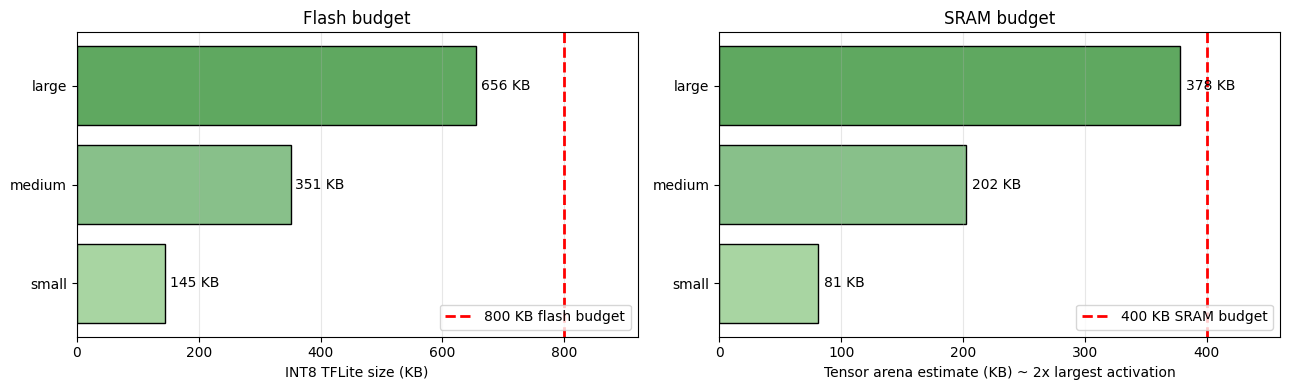

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = list(variants.keys())
int8_sizes = [tflite_results[n]["int8_kb"] for n in names]
arena_sizes = [analysis[n]["arena_est_kb"] for n in names]
colors_size = ["#a8d5a2", "#88c08a", "#5fa860"]

# Flash budget
axes[0].barh(names, int8_sizes, color=colors_size, edgecolor="black")
axes[0].axvline(ESP32_FLASH_KB, color="red", linestyle="--", linewidth=2,
                label=f"800 KB flash budget")
for i, (n, s) in enumerate(zip(names, int8_sizes)):
    axes[0].text(s + 8, i, f"{s:.0f} KB", va="center", fontsize=10)
axes[0].set_xlabel("INT8 TFLite size (KB)")
axes[0].set_title("Flash budget")
axes[0].legend(loc="lower right")
axes[0].set_xlim(0, ESP32_FLASH_KB * 1.15)
axes[0].grid(axis="x", alpha=0.3)

# SRAM budget
axes[1].barh(names, arena_sizes, color=colors_size, edgecolor="black")
axes[1].axvline(ESP32_SRAM_KB, color="red", linestyle="--", linewidth=2,
                label=f"400 KB SRAM budget")
for i, (n, s) in enumerate(zip(names, arena_sizes)):
    axes[1].text(s + 5, i, f"{s:.0f} KB", va="center", fontsize=10)
axes[1].set_xlabel("Tensor arena estimate (KB) ~ 2x largest activation")
axes[1].set_title("SRAM budget")
axes[1].legend(loc="lower right")
axes[1].set_xlim(0, ESP32_SRAM_KB * 1.15)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_size_budgets.png", bbox_inches="tight")
plt.show()


## 8. Untrained heatmap output (sanity check)

Random initial weights produce a near-uniform sigmoid output around 0.5. After training, this will collapse toward zero everywhere except at the predicted person locations.


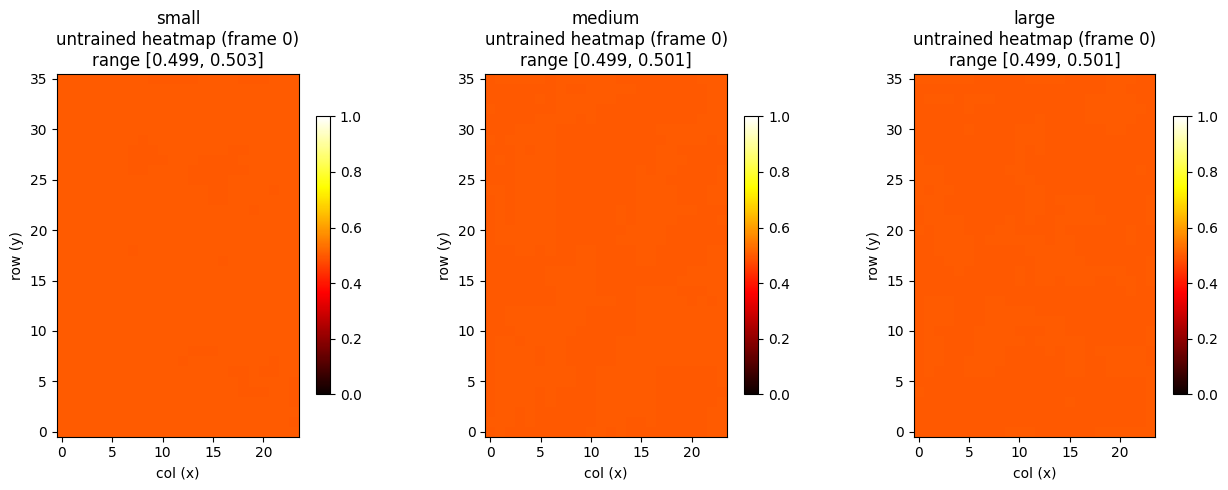

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, name in zip(axes, variants):
    hm, cnt = forward_results[name]
    im = ax.imshow(hm[0, :, :, 0], cmap="hot", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"{name}\nuntrained heatmap (frame 0)\nrange [{hm.min():.3f}, {hm.max():.3f}]")
    ax.set_xlabel("col (x)")
    ax.set_ylabel("row (y)")
    plt.colorbar(im, ax=ax, fraction=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_untrained_output.png", bbox_inches="tight")
plt.show()


## 9. PDF briefing

In [12]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image as RLImage, PageBreak,
)
from PIL import Image as PILImage

OUT_PDF = OTHER_FILES / "eda_model.pdf"

ss = getSampleStyleSheet()
H1   = ParagraphStyle("H1",    parent=ss["Heading1"], fontSize=14, spaceAfter=4, spaceBefore=8,
                               textColor=colors.HexColor("#0b3d91"))
H2   = ParagraphStyle("H2",    parent=ss["Heading2"], fontSize=11, spaceAfter=2, spaceBefore=6,
                               textColor=colors.HexColor("#0b3d91"))
BODY = ParagraphStyle("body",  parent=ss["BodyText"], fontSize=8.5, leading=11)
SMALL= ParagraphStyle("small", parent=ss["BodyText"], fontSize=7.5, leading=9.5)

def tbl(data, col_widths=None, font_size=7.5, header=True):
    t = Table(data, colWidths=col_widths)
    style = [
        ("FONT", (0, 0), (-1, -1), "Helvetica", font_size),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 3),
        ("RIGHTPADDING", (0, 0), (-1, -1), 3),
        ("TOPPADDING", (0, 0), (-1, -1), 1.5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 1.5),
    ]
    if header:
        style += [
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#e8eef7")),
            ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", font_size),
        ]
    t.setStyle(TableStyle(style))
    return t

def fig(path, width=16*cm):
    p = Path(path)
    if not p.exists():
        return Paragraph(f"<i>(missing: {p.name})</i>", SMALL)
    with PILImage.open(p) as im:
        w, h = im.size
    return RLImage(str(p), width=width, height=width * (h / w))


doc = SimpleDocTemplate(
    str(OUT_PDF), pagesize=A4,
    leftMargin=1.5*cm, rightMargin=1.5*cm,
    topMargin=1.2*cm, bottomMargin=1.2*cm,
    title="Model Architecture Briefing - Multi-Person UWB Localization",
)
story = []

# ---- Header ----
story.append(Paragraph("Model Architecture Briefing - Multi-Person UWB Localization", H1))
story.append(Paragraph(
    f"Generated {datetime.now():%Y-%m-%d %H:%M} - "
    f"3 size variants - Hybrid heatmap + count head - "
    f"All TFLM-supported ops - "
    f"INT8 quantized; tested on untrained weights for size verification",
    SMALL,
))
story.append(Spacer(1, 4))

# ---- 1. Architecture diagram ----
story.append(Paragraph("1. Architecture (shared across variants)", H2))
story.append(Paragraph(
    "All three variants share the same encoder + decoder + count head structure; "
    "they differ only in the channel widths of each stage. The encoder maps the "
    "(8, 6, 3, 105, 2) stacked input to a flat feature vector via a depthwise temporal "
    "collapse followed by four range-direction convolutions. The heatmap decoder "
    "expands a (9, 6) bottleneck back to the (36, 24) room grid via two 2x upsampling "
    "stages. The count head is a small MLP on the same bottleneck features.",
    BODY,
))
story.append(fig(FIG_DIR / "model_architecture.png", width=17*cm))

# ---- 2. Variant configurations ----
story.append(PageBreak())
story.append(Paragraph("2. Variant configurations", H2))
story.append(Paragraph(
    "The three variants are designed to span the size budget. Channel widths increase "
    "monotonically; the decoder bottleneck channel count <i>c_b</i> is small to keep the "
    "Dense projection from dominating the parameter budget.",
    BODY,
))
var_rows = [["Variant", "Encoder channels", "Feature width", "c_b", "Decoder ch (c0, c1, c2)", "Count hidden"]]
for name, v in MODEL_VARIANTS.items():
    var_rows.append([
        name,
        ", ".join(str(x) for x in v.enc_filters),
        str(v.feature_width),
        str(v.bottleneck_chan),
        ", ".join(str(x) for x in v.decoder_channels),
        str(v.count_hidden),
    ])
story.append(tbl(var_rows, col_widths=[2*cm, 4*cm, 2.5*cm, 1.5*cm, 4*cm, 2.5*cm]))

# ---- 3. Sizes ----
story.append(Spacer(1, 6))
story.append(Paragraph("3. Parameter counts and TFLite binary sizes", H2))
story.append(Paragraph(
    "TFLite sizes measured from real conversions (concrete-function path, fixed batch=1, "
    "BN moving stats baked as constants by save+reload). INT8 quantization is full "
    "post-training quantization with random calibration data; trained models will use "
    "real preprocessed CIR snippets and produce the same binary size.",
    BODY,
))
size_rows = [["Variant", "Params", "Float32 (raw)", "Float32 TFLite", "INT8 TFLite", "Compression vs raw"]]
for name in variants:
    res = tflite_results[name]
    raw_kb = res["params"] * 4 / 1024
    int8_kb = res["int8_kb"]
    f32_kb = res["f32_kb"]
    compress = raw_kb / int8_kb if int8_kb > 0 else 0
    size_rows.append([
        name,
        f"{res['params']:,}",
        f"{raw_kb:.1f} KB",
        f"{f32_kb:.1f} KB",
        f"{int8_kb:.1f} KB",
        f"{compress:.2f}x",
    ])
story.append(tbl(size_rows, col_widths=[2*cm, 2.2*cm, 2.5*cm, 2.5*cm, 2.5*cm, 2.5*cm]))

# ---- 4. Budget compliance ----
story.append(Spacer(1, 6))
story.append(Paragraph("4. ESP32-S3 budget compliance", H2))
budget_rows = [["Variant", "INT8 size", "Flash limit", "Flash OK?",
                "Largest tensor", "Arena est.", "SRAM limit", "SRAM OK?"]]
for name in variants:
    res = tflite_results[name]
    info = analysis[name]
    largest_shape, largest_bytes = info["largest_tensor"]
    arena_kb = info["arena_est_kb"]
    flash_ok = "Y" if res["int8_kb"] < ESP32_FLASH_KB else "N"
    sram_ok = "Y" if arena_kb < ESP32_SRAM_KB else "N"
    budget_rows.append([
        name,
        f"{res['int8_kb']:.1f} KB",
        f"{ESP32_FLASH_KB} KB",
        flash_ok,
        f"{largest_bytes/1024:.1f} KB",
        f"{arena_kb:.1f} KB",
        f"{ESP32_SRAM_KB} KB",
        sram_ok,
    ])
story.append(tbl(budget_rows, col_widths=[1.6*cm, 1.8*cm, 1.6*cm, 1.4*cm, 2*cm, 2*cm, 1.6*cm, 1.4*cm], font_size=7))

story.append(Spacer(1, 4))
story.append(fig(FIG_DIR / "model_size_budgets.png", width=17*cm))

# ---- 5. Op set ----
story.append(PageBreak())
story.append(Paragraph("5. TFLite operation set", H2))
story.append(Paragraph(
    "The INT8 graph contains only operations on the TFLM supported list. No LSTM/GRU/RNN, "
    "no Conv2DTranspose. Counts shown for the medium variant; the small and large variants "
    "use an identical op set.",
    BODY,
))
op_counts = analysis["medium"]["op_counts"]
op_rows = [["Op", "Count", "TFLM supported?"]]
for op, n in sorted(op_counts.items()):
    # All listed ops are in the assignment's TFLM whitelist
    op_rows.append([op, str(n), "Yes"])
story.append(tbl(op_rows, col_widths=[6*cm, 2*cm, 4*cm]))

# ---- 6. Untrained output ----
story.append(Spacer(1, 6))
story.append(Paragraph("6. Untrained output sanity check", H2))
story.append(Paragraph(
    "Untrained models produce a near-uniform sigmoid heatmap around 0.5 -- the network "
    "has not yet learned to distinguish presence from absence. After training, the "
    "heatmap collapses toward zero everywhere except at predicted person cells.",
    BODY,
))
story.append(fig(FIG_DIR / "model_untrained_output.png", width=17*cm))

# ---- 7. Conversion recipe ----
story.append(Spacer(1, 6))
story.append(Paragraph("7. Conversion recipe", H2))
story.append(Paragraph(
    "TFLite INT8 conversion of a Keras model with BatchNormalization is fragile. Several "
    "common paths fail: dynamic batch with from_keras_model() falls back to TF Conv2D; "
    "from_concrete_functions() raises READ_VARIABLE errors during INT8 calibration; "
    "from_saved_model() likewise fails when BN moving stats are not folded. The reliable "
    "recipe used here, encapsulated in <font face='Courier'>convert_to_tflite()</font>, is:",
    BODY,
))
recipe = [
    "1. Build a fresh inference-only model with batch_size=1.",
    "2. Copy weights from the trained dynamic-batch model.",
    "3. Run a dummy forward pass with training=False.",
    "4. Save as .keras, reload via load_model() (this bakes BN moving stats as constants).",
    "5. Convert with TFLiteConverter.from_keras_model() and INT8 representative dataset.",
]
for line in recipe:
    story.append(Paragraph(line, BODY))

doc.build(story)
print(f"Wrote {OUT_PDF}  ({OUT_PDF.stat().st_size/1024:.1f} KB)")


Wrote /home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/eda_model.pdf  (258.8 KB)
